Visualize what best fit parameters mean

In [2]:
import zeus21
from escripts import eMCMC
from escripts import edata
from escripts import eplots
import importlib
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable

In [3]:
best_fit = [0.64, -0.06, -0.01, 0.12, 11.85, 0.08, -0.99, -0.05, 0.01, 0.5, 0.27]

In [4]:
sigma_UV = best_fit[-3]

# $M_{\rm{UV}}$ Gaussians

In [5]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [6]:
param_data = eMCMC.build_param_data({})

In [7]:
my_UVLF = eMCMC.UVLF(sorted_data, param_data)

In [1]:
def plot_MUV_dist(my_UVLF, zs, param_values, Mhtab):
    fig, axs = plt.subplots(1, 2, width_ratios = (13, 1))
    MUV_range = np.linspace(-15, -24, 500)
    axs[0].invert_xaxis()
    
    gradient = eplots.interpolate_colors([eplots.red, eplots.navy], len(Mhtab), show_plot = False)
    cmap = ListedColormap(gradient)
    norm = BoundaryNorm(np.arange(np.log10(min(Mhtab)), np.log10(max(Mhtab))+1, 1), cmap.N)
    
    my_UVLF.HMFintclass.Mhtab = Mhtab 
    
    for z, ls in zip(zs, ['-', '--']):
    
        params = my_UVLF.time_evolution(param_values, z)
        astroparams = my_UVLF.param_wrapper(params)
        SFRlist = zeus21.sfrd.SFR_II(astroparams, my_UVLF.CosmoParams, my_UVLF.HMFintclass, Mhtab, z, z)
        MUVbarlist = zeus21.UVLFs.MUV_of_SFR(SFRlist, astroparams._kappaUV)
        MUVbarlist = np.fmin(MUVbarlist, zeus21.constants._MAGMAX)

        axs[0].plot(MUV_range[0], 0, ls = ls, color = 'black', label = f'$z={z}$') # Make invisible line for the legend purposes


        for sigUV, MUV_bar, Mh in zip(params[-1], MUVbarlist, Mhtab):
            color = cmap(norm(np.log10(Mh)))
            axs[0].plot(MUV_range, gaussian(MUV_range, sigUV, MUV_bar), color = color, ls = ls)
            
    sm = ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, cax = axs[1], ticks=np.log10(Mhtab)+0.5, boundaries=np.log10(Mhtab), format='%.1f')
    cbar.set_label(r'$\log_{10}(M_h/M_{\odot})$')

    axs[0].set_ylabel(r'$P(M_{\rm{UV}}|M_h)$')
    axs[0].set_xlabel(r'$M_{\rm{UV}}$ [mag]')
    axs[0].legend(loc = 'upper left')
    

    return fig

In [246]:
def gaussian(MUV_range, sigma_UV, MUV_bar):
    return (1/(sigma_UV * np.sqrt(2*np.pi)))*np.exp(-(MUV_range-MUV_bar)**2/(2*sigma_UV**2))

In [247]:
Mhtab = np.logspace(9, 12.1, 5)

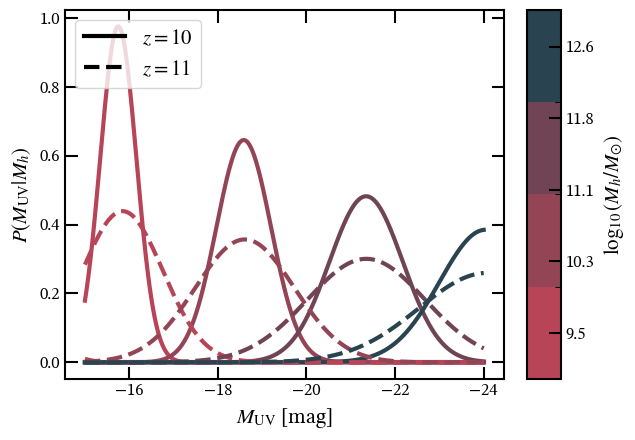

In [248]:
fig = plot_MUV_dist(my_UVLF, [10, 11], best_fit, Mhtab)

# SFE($M_h$) for different $z$

In [50]:
alpha = 0.71
beta = 0.12
logeps = -1.42
logMc = 11.75

In [51]:
Mh = np.logspace(8, 17, 100)

In [52]:
sfe = 10**logeps/((Mh/10**logMc)**-alpha + (Mh/10**logMc)**-beta)

Text(0.5, 0, '$M_h$')

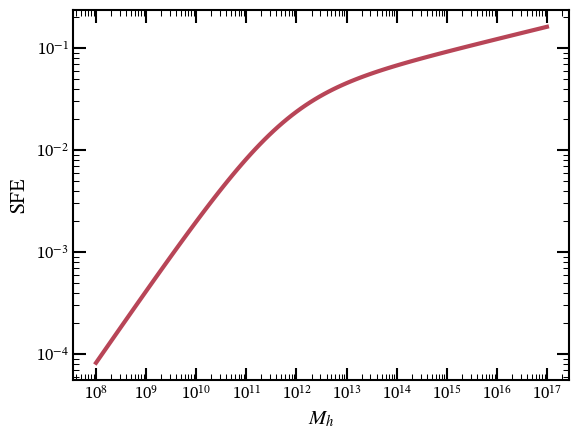

In [53]:
plt.plot(Mh, sfe)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('SFE')
plt.xlabel(r'$M_h$')